In [29]:
import pandas as pd
import numpy as  np
import seaborn as sns
import scipy as sc
import statsmodels.formula.api as sfm

In [5]:
bg_nuc = pd.read_csv('../data/20231204_Mbel_hs_5fold_background.nuc', sep="\t")
peak_nuc = pd.read_csv('../data/20231204_Mbel_hs_5fold.nuc', sep="\t")

In [7]:
peak_nuc["frac_GC"] = (peak_nuc["11_num_C"]+peak_nuc["12_num_G"])/peak_nuc["16_seq_len"]
bg_nuc["frac_GC"] = (bg_nuc["7_num_C"]+bg_nuc["8_num_G"])/bg_nuc["12_seq_len"]

/tmp/ipykernel_3592989/1552812762.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(bg_nuc["frac_GC"])
/tmp/ipykernel_3592989/1552812762.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(peak_nuc["frac_GC"])


<Axes: xlabel='frac_GC', ylabel='Density'>

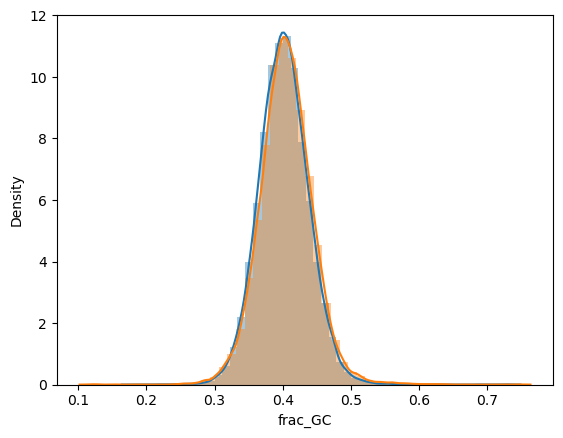

In [16]:
sns.distplot(bg_nuc["frac_GC"])
sns.distplot(peak_nuc["frac_GC"])

In [18]:
sc.stats.ttest_ind(bg_nuc["frac_GC"], peak_nuc["frac_GC"])

TtestResult(statistic=-13.114441013363056, pvalue=2.989378634797802e-39, df=79667.0)

In [27]:
bg_nuc["frac_GC"].mean()

0.40145519153090903

In [28]:
peak_nuc["frac_GC"].mean()

0.4049874715935779

In [31]:
bg_nuc["peak"] = [False for i in range(bg_nuc.shape[0])]
peak_nuc["peak"] = [True for i in range(peak_nuc.shape[0])]
all_nuc = pd.concat([bg_nuc, peak_nuc])

In [36]:
nuc_m = sfm.ols("frac_GC ~ peak", data=all_nuc)
nuc_fit = nuc_m.fit()
nuc_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                frac_GC   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     172.0
Date:                Thu, 22 Feb 2024   Prob (F-statistic):           2.99e-39
Time:                        10:41:49   Log-Likelihood:             1.4746e+05
No. Observations:               79669   AIC:                        -2.949e+05
Df Residuals:                   79667   BIC:                        -2.949e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.4015      0.000   2107.950      0.000       0.401       0.402
peak[T.True]     0.0035      0.000     13.114      0.000       0.003       0.004
==============================================================================
Omnibus:                     5999.300   Durbin-Watson:                   1.477
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            23973.723
Skew:                           0.291   Prob(JB):                         0.00
Kurtosis:                       5.623   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
bg_nuc_ss = pd.read_csv('../data/20231204_Mbel_hs_5fold_background_13kss.nuc', sep="\t")
peak_nuc_ss = pd.read_csv('../data/20231204_Mbel_hs_5fold_13kss.nuc', sep="\t")

In [21]:
peak_nuc_ss["frac_GC"] = (peak_nuc_ss["11_num_C"]+peak_nuc_ss["12_num_G"])/peak_nuc_ss["16_seq_len"]
bg_nuc_ss["frac_GC"] = (bg_nuc_ss["7_num_C"]+bg_nuc_ss["8_num_G"])/bg_nuc_ss["12_seq_len"]

/tmp/ipykernel_3592989/4135932631.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(bg_nuc_ss["frac_GC"])
/tmp/ipykernel_3592989/4135932631.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(peak_nuc_ss["frac_GC"])


<Axes: xlabel='frac_GC', ylabel='Density'>

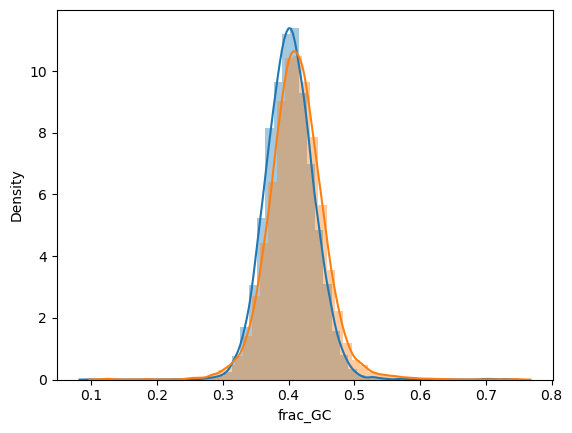

In [22]:
sns.distplot(bg_nuc_ss["frac_GC"])
sns.distplot(peak_nuc_ss["frac_GC"])

In [23]:
sc.stats.ttest_ind(bg_nuc_ss["frac_GC"], peak_nuc_ss["frac_GC"])

TtestResult(statistic=-20.098878817682152, pvalue=3.225773217116259e-89, df=27958.0)

In [25]:
bg_nuc_ss["frac_GC"].mean()

0.40205482698961326

In [26]:
peak_nuc_ss["frac_GC"].mean()

0.41166090423880003

In [37]:
bg_nuc_ss["peak"] = [False for i in range(bg_nuc_ss.shape[0])]
peak_nuc_ss["peak"] = [True for i in range(peak_nuc_ss.shape[0])]
all_nuc_ss = pd.concat([bg_nuc_ss, peak_nuc_ss])

In [39]:
nuc_m_ss = sfm.ols("frac_GC ~ peak", data=all_nuc_ss)
nuc_ss_fit = nuc_m_ss.fit()
nuc_ss_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                frac_GC   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     404.0
Date:                Thu, 22 Feb 2024   Prob (F-statistic):           3.23e-89
Time:                        10:43:43   Log-Likelihood:                 50356.
No. Observations:               27960   AIC:                        -1.007e+05
Df Residuals:                   27958   BIC:                        -1.007e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.4021      0.000   1189.711      0.000       0.401       0.403
peak[T.True]     0.0096      0.000     20.099      0.000       0.009       0.011
==============================================================================
Omnibus:                     3158.506   Durbin-Watson:                   1.978
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            20090.449
Skew:                           0.354   Prob(JB):                         0.00
Kurtosis:                       7.092   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""